In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency, ttest_ind

In [2]:
df = pd.read_csv('C:/Users/HTP/Downloads/Pregnancy During the COVID-19 Pandemic.csv')


FileNotFoundError: [Errno 2] No such file or directory: 'C:/Users/HTP/Downloads/Pregnancy During the COVID-19 Pandemic.csv'

In [ ]:
print(df.info())
print(df.describe())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10772 entries, 0 to 10771
Data columns (total 16 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   OSF_ID                                      10772 non-null  int64  
 1   Maternal_Age                                10661 non-null  float64
 2   Household_Income                            10521 non-null  object 
 3   Maternal_Education                          10595 non-null  object 
 4   Edinburgh_Postnatal_Depression_Scale        9598 non-null   float64
 5   PROMIS_Anxiety                              9566 non-null   float64
 6   Gestational_Age_At_Birth                    6734 non-null   float64
 7   Delivery_Date(converted to month and year)  6733 non-null   object 
 8   Birth_Length                                5480 non-null   float64
 9   Birth_Weight                                6078 non-null   float64
 10  Delivery_M

In [ ]:
#indentifying rows to drop
rows_to_drop= df[(df['PROMIS_Anxiety'].isnull())&(df['Delivery_Date(converted to month and year)'].isnull())&(
    df['Threaten_Life']==' ')&(df['Threaten_Baby_Danger']==' ')&(df['Threaten_Baby_Harm']==' ')].index


df.drop(rows_to_drop, inplace=True)
df.shape

(10292, 16)

In [ ]:
df.drop(columns=['OSF_ID','Language'], inplace=True)

In [ ]:
df


,Maternal_Age,Household_Income,Maternal_Education,Edinburgh_Postnatal_Depression_Scale,PROMIS_Anxiety,Gestational_Age_At_Birth,Delivery_Date(converted to month and year),Birth_Length,Birth_Weight,Delivery_Mode,NICU_Stay,Threaten_Life,Threaten_Baby_Danger,Threaten_Baby_Harm
0,38.3,"$200,000+",Masters degree,9.0,13.0,39.71,Dec2020,49.20,3431.0,Vaginally,No,2,3,27
1,34.6,"$200,000+",Undergraduate degree,4.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,2,33,92
3,28.8,"$100,000 -$124,999",Masters degree,9.0,20.0,38.57,Dec2020,41.00,2534.0,Vaginally,No,53,67,54
4,36.5,"$40,000-$69,999",Undergraduate degree,14.0,20.0,39.86,Oct2020,53.34,3714.0,Caesarean-section (c-section),No,23,32,71
5,38.3,"$150,000 - $174,999",Undergraduate degree,3.0,8.0,38.57,Jun2020,NaN,NaN,NaN,NaN,29,36,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10766,32.7,"$70,000-$99,999",High school diploma,15.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,54,64,75
10767,38.3,"$100,000 -$124,999",Undergraduate degree,10.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,54,62,74
10769,27.7,"$20,000- $39,999",College/trade school,4.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,21,93,76
10770,23.0,"$20,000- $39,999",College/trade school,12.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,65,94,94


## Mức độ lo lắng của phụ nữ mang thai  

In [ ]:
mask_25_38 = (df['Maternal_Age'] >= 25) & (df['Maternal_Age'] <= 38)
mask_over_42 = df['Maternal_Age'] > 42
anxiety_25_38 = df.loc[mask_25_38, 'PROMIS_Anxiety'].mean()
anxiety_over_42 = df.loc[mask_over_42, 'PROMIS_Anxiety'].mean()
print(f"Giá trị trung bình của Anxiety cho nhóm 25-38 tuổi: {anxiety_25_38:.2f}")
print(f"Giá trị trung bình của Anxiety cho nhóm trên 42 tuổi: {anxiety_over_42:.2f}")


Giá trị trung bình của Anxiety cho nhóm 25-38 tuổi: 18.59
Giá trị trung bình của Anxiety cho nhóm trên 42 tuổi: 17.72


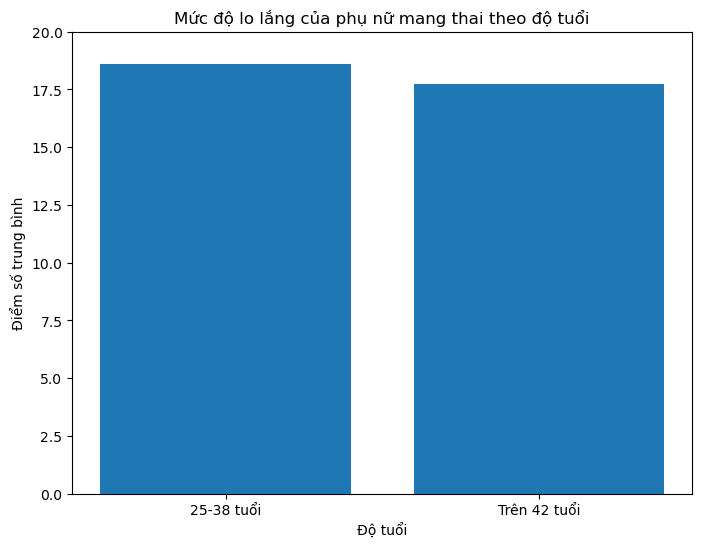

In [ ]:
# Vẽ biểu đồ
plt.figure(figsize=(8,6))
labels = ['25-38 tuổi', 'Trên 42 tuổi']
values = [anxiety_25_38, anxiety_over_42]
plt.bar(labels, values)
plt.ylim(0, 20)
plt.title('Mức độ lo lắng của phụ nữ mang thai theo độ tuổi')
plt.xlabel('Độ tuổi')
plt.ylabel('Điểm số trung bình')

plt.show()

In [ ]:
## Giải thích biểu đồ trên


## Mức độ trầm cảm của phụ nữ mang thai theo thang edinburgh

In [ ]:
mask_25_38 = (df['Maternal_Age'] >= 25) & (df['Maternal_Age'] <= 38)
mask_over_42 = df['Maternal_Age'] > 42
Depression_25_38 = df.loc[mask_25_38, 'Edinburgh_Postnatal_Depression_Scale'].mean()
Depression_over_42 = df.loc[mask_over_42, 'Edinburgh_Postnatal_Depression_Scale'].mean()
print(f"Giá trị trung bình của EDPS cho nhóm 25-38 tuổi: {Depression_25_38:.2f}")
print(f"Giá trị trung bình của EDPS cho nhóm trên 42 tuổi: {Depression_over_42:.2f}")


Giá trị trung bình của EDPS cho nhóm 25-38 tuổi: 10.07
Giá trị trung bình của EDPS cho nhóm trên 42 tuổi: 9.47


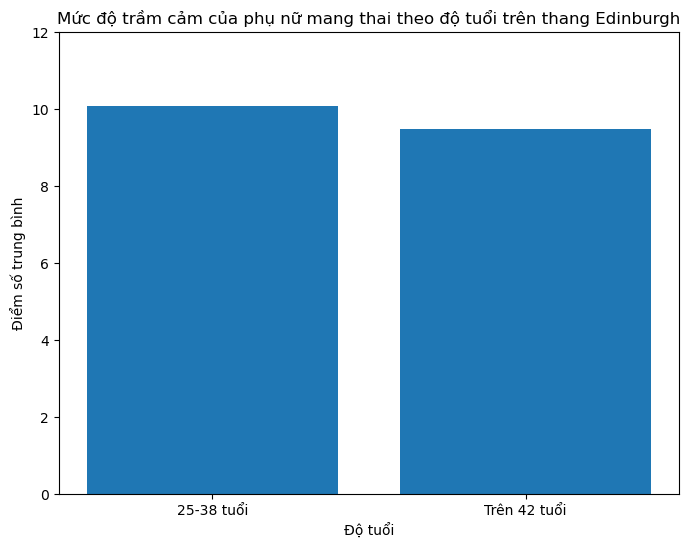

In [ ]:
# Vẽ biểu đồ
plt.figure(figsize=(8,6))
labels = ['25-38 tuổi', 'Trên 42 tuổi']
values = [Depression_25_38, Depression_over_42]

plt.bar(labels, values)
plt.ylim(0,12)
plt.title('Mức độ trầm cảm của phụ nữ mang thai theo độ tuổi trên thang Edinburgh')
plt.xlabel('Độ tuổi')
plt.ylabel('Điểm số trung bình')

plt.show()

In [ ]:
df_filtered = df.dropna(subset=['Threaten_Life', 'Threaten_Baby_Danger', 'Threaten_Baby_Harm'])

In [ ]:
df.dropna(subset=['Threaten_Life', 'Threaten_Baby_Danger', 'Threaten_Baby_Harm'])

,Maternal_Age,Household_Income,Maternal_Education,Edinburgh_Postnatal_Depression_Scale,PROMIS_Anxiety,Gestational_Age_At_Birth,Delivery_Date(converted to month and year),Birth_Length,Birth_Weight,Delivery_Mode,NICU_Stay,Threaten_Life,Threaten_Baby_Danger,Threaten_Baby_Harm
0,38.3,"$200,000+",Masters degree,9.0,13.0,39.71,Dec2020,49.20,3431.0,Vaginally,No,2,3,27
1,34.6,"$200,000+",Undergraduate degree,4.0,17.0,NaN,NaN,NaN,NaN,NaN,NaN,2,33,92
3,28.8,"$100,000 -$124,999",Masters degree,9.0,20.0,38.57,Dec2020,41.00,2534.0,Vaginally,No,53,67,54
4,36.5,"$40,000-$69,999",Undergraduate degree,14.0,20.0,39.86,Oct2020,53.34,3714.0,Caesarean-section (c-section),No,23,32,71
5,38.3,"$150,000 - $174,999",Undergraduate degree,3.0,8.0,38.57,Jun2020,NaN,NaN,NaN,NaN,29,36,33
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10766,32.7,"$70,000-$99,999",High school diploma,15.0,27.0,NaN,NaN,NaN,NaN,NaN,NaN,54,64,75
10767,38.3,"$100,000 -$124,999",Undergraduate degree,10.0,18.0,NaN,NaN,NaN,NaN,NaN,NaN,54,62,74
10769,27.7,"$20,000- $39,999",College/trade school,4.0,15.0,NaN,NaN,NaN,NaN,NaN,NaN,21,93,76
10770,23.0,"$20,000- $39,999",College/trade school,12.0,19.0,NaN,NaN,NaN,NaN,NaN,NaN,65,94,94


In [ ]:
invalid_values = df['Household_Income'].str.contains(r'\+')

In [ ]:
df['Household_Income'] = df['Household_Income'].str.replace(r'\+', '').astype(float)

ValueError: could not convert string to float: '$200,000+'

In [ ]:
could not convert string to float: '$200,000+'

SyntaxError: invalid syntax (343677197.py, line 1)

In [ ]:
df['Household_Income'] = df['Household_Income'].str.replace(',', '').str.replace('$', '').str.replace('+', '')

In [ ]:
df['Household_Income'] = df['Household_Income'].astype(float)

ValueError: could not convert string to float: '100000 -124999'

In [ ]:
df['Household_Income'] = df['Household_Income'].str.replace(',', '').str.replace('$', '').str.replace('+', '').str.replace('-', '')


In [ ]:
df['Household_Income'] = df['Household_Income'].str.extract('(\+)', expand=False).astype(float)

<>:1: SyntaxWarning: invalid escape sequence '\+'
<>:1: SyntaxWarning: invalid escape sequence '\+'
C:\Users\HTP\AppData\Local\Temp\ipykernel_20496\1192048596.py:1: SyntaxWarning: invalid escape sequence '\+'
  df['Household_Income'] = df['Household_Income'].str.extract('(\+)', expand=False).astype(float)
C:\Users\HTP\AppData\Local\Temp\ipykernel_20496\1192048596.py:1: SyntaxWarning: invalid escape sequence '\+'
  df['Household_Income'] = df['Household_Income'].str.extract('(\+)', expand=False).astype(float)


AttributeError: Can only use .str accessor with string values!